# 概要
sklearnのBoston house prices datasetsのサンプルシナリオ。(回帰予測)

# 追加インストールライブラリ
- pandas<br>
  `pip install pandas`
- sklearn<br>
  `pip install scikit-learn`
- matplotlib<br>
  `pip install matplotlib`

# データの準備

In [1]:
import pandas as pd
import numpy as np
from sklearn.utils import Bunch

def load_boston():
    """ボストン住宅価格データセットを読み込む。sklearnから削除されていたため、urlから直で取得"""
    data_url = "http://lib.stat.cmu.edu/datasets/boston"

    raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    
    target = raw_df.values[1::2, 2]
    feature_names = [
        "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD",
        "TAX", "PTRATIO", "B", "LSTAT"
    ]

    return Bunch(data=data, target=target, feature_names=feature_names)

In [2]:
boston = load_boston()
dfFeature = pd.DataFrame(boston.data, columns=boston.feature_names)
dfFeature

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [3]:
boston.target.shape

(506,)

In [4]:
from sklearn.model_selection import train_test_split
trainData, testData, trainLabel, testLabel = train_test_split(boston.data, boston.target, test_size=0.2, random_state=42)
trainData.shape, testData.shape, trainLabel.shape, testLabel.shape

((404, 13), (102, 13), (404,), (102,))

# 学習データのみを利用してスケーリング
学習データの最大値と最小値を利用してMinMaxScalingを行います。<br>
複数のSAMACTを同一SAMACTで制御する場合、scalerExpのインスタンスも複数用意する必要があります。<br>
※MinMaxScalerは関数ではなく、クラスのため

推論時は、学習データから作成されたScalerを利用して、スケーリングします。<br>
推論データは事前に得られないことを想定した記述です。

In [5]:
from sklearn.preprocessing import MinMaxScaler
scalerExp = MinMaxScaler()
scaledExpTrain = scalerExp.fit_transform(trainData)
scaledExpTest = scalerExp.transform(testData)
scaledExpTrain

array([[1.68762759e-01, 0.00000000e+00, 6.42962963e-01, ...,
        8.08510638e-01, 8.80427656e-01, 6.39624724e-01],
       [6.95009416e-03, 0.00000000e+00, 2.74074074e-01, ...,
        8.93617021e-01, 9.96772404e-01, 1.85982340e-01],
       [2.87746689e-04, 3.50000000e-01, 1.97037037e-01, ...,
        4.57446809e-01, 9.12627969e-01, 1.68322296e-01],
       ...,
       [6.68786251e-05, 8.00000000e-01, 4.70370370e-02, ...,
        4.68085106e-01, 9.84971506e-01, 1.17549669e-01],
       [1.25342233e-01, 0.00000000e+00, 6.42962963e-01, ...,
        8.08510638e-01, 2.76186394e-01, 5.94370861e-01],
       [2.46945108e-03, 0.00000000e+00, 2.89629630e-01, ...,
        8.82978723e-01, 1.77719502e-01, 2.45584989e-01]])

In [6]:
scalerObj = MinMaxScaler()
scaledObjTrain = scalerObj.fit_transform(trainLabel.reshape(-1, 1))
scaledObjTest = scalerObj.transform(testLabel.reshape(-1, 1))
scaledObjTrain.shape

(404, 1)

# SAMACTモデルの構築

In [7]:
from samact import *

# 1データに16個入力ユニットを利用する方式。
inputLayer = NeuronFocusEncodeLayer(len(boston.feature_names), 16)
hiddenLayer = SAMLayer(128, LayerProperty(a=3, p=0.75), Step(), Step())
# 出力を16個のニューロンで表現する方式。
outputLayer = SAMLayer(16, LayerProperty(a=3, p=0.75), Step(), Step())
decoder = NeuronFocusDecodeLayer()

model = Sequential(inputLayer, decoder, [hiddenLayer, outputLayer])
model.Compile(32)
model

Model summary
  Encoder: NeuronFocusEncode(nUnits=13, nNeuronPerExpVar=16)
  Layers:
    [0] SAMLayer(nUnits=128, gradAct=Step(a=0, b=6, g=18), teacherAct=Step(a=0, b=6, g=18))
    [1] SAMLayer(nUnits=16, gradAct=Step(a=0, b=6, g=18), teacherAct=Step(a=0, b=6, g=18))
  Decoder: NeuronFocusDecode(nObjectives=1)
  tC: 32

# 学習
評価指標はmseを指定するのが一般的です。

In [8]:
learnProperty = LearningProperty(eta=5, iota=2, decayPeriod=1)

In [9]:
fitResult = model.Fit(scaledExpTrain, scaledObjTrain, 10, learnProperty, metrics='mse')
fitResult.metrics

[0.012986478513770994,
 0.010365222743542409,
 0.008883979394636029,
 0.008564258863928592,
 0.008214128826815995,
 0.007765895906599726,
 0.007534319368170695,
 0.007438195899281873,
 0.007397304904512231,
 0.007363178891355494]

# 学習結果の保存と読み込み
モデルは、ファイルとして入出力が可能です。


In [10]:
model.Save('reg.h5')
loadModel = Pretrained('reg.h5')
loadModel

Model summary
  Encoder: NeuronFocusEncode(nUnits=13, nNeuronPerExpVar=16)
  Layers:
    [0] SAMLayer(nUnits=128, gradAct=Step(a=0, b=6, g=18), teacherAct=Step(a=0, b=6, g=18))
    [1] SAMLayer(nUnits=16, gradAct=Step(a=0, b=6, g=18), teacherAct=Step(a=0, b=6, g=18))
  Decoder: NeuronFocusDecode(nObjectives=1)
  tC: 32

# 推論
SAMACTモデルにデータセットを推論させる。

In [11]:
evalResult = model.Evaluate(scaledExpTest, scaledObjTest, metrics='mse')
evalResult.metrics

0.015475603679212808

In [12]:
evalResultLoad = loadModel.Evaluate(scaledExpTest, scaledObjTest, metrics='mse')
evalResultLoad.metrics

0.015475603679212808

In [13]:
evalResult.predicts[:5]

[array([0.52148438]),
 array([0.65625]),
 array([0.28125]),
 array([0.49414062]),
 array([0.24609375])]

In [14]:
dfPred = pd.Series(np.concatenate(evalResult.predicts))
dfGolden = pd.Series(scaledObjTest.flatten())
dfPredVsGolden = pd.concat([dfPred, dfGolden], axis=1)
dfPredVsGolden.columns = ['pred', 'golden']

In [15]:
dfGolden

0      0.413333
1      0.608889
2      0.191111
3      0.395556
4      0.246667
         ...   
97     0.286667
98     0.102222
99     0.271111
100    0.388889
101    0.364444
Length: 102, dtype: float64

学習に使用していないテスト用データに対する推論結果は下記です。<br>
predがSAMACTの予測値、goldenが実際の値です。

<Axes: >

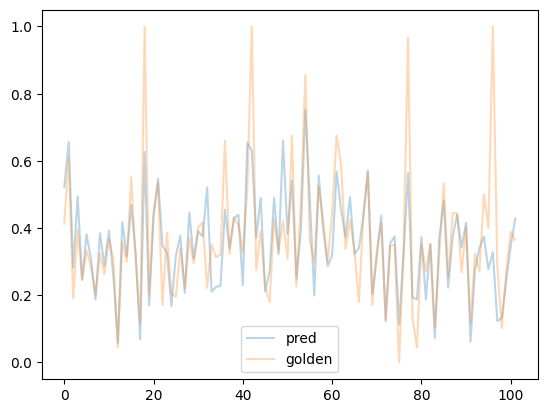

In [16]:
dfPredVsGolden.plot(alpha=0.3)

<Axes: ylabel='Frequency'>

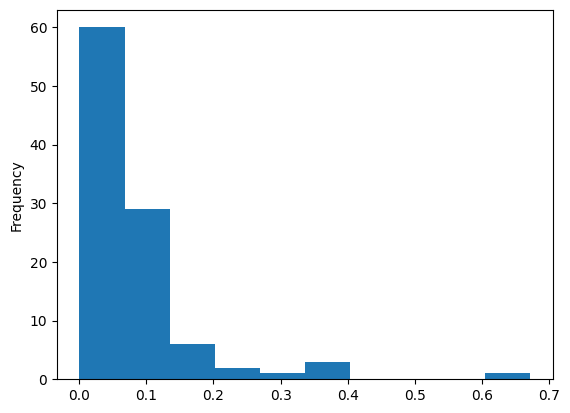

In [17]:
error = dfPred-dfGolden
error.abs().plot.hist()

In [18]:
trainPredicts = model.Evaluate(scaledExpTrain, scaledObjTrain, metrics='mse').predicts
trainPredicts[:5]

[array([0.18164062]),
 array([0.36523438]),
 array([0.4296875]),
 array([0.24414062]),
 array([0.31054688])]

学習に使用したデータに対する推論結果は下記です。<br>
predがSAMACTの予測値、goldenが実際の値です。

<Axes: >

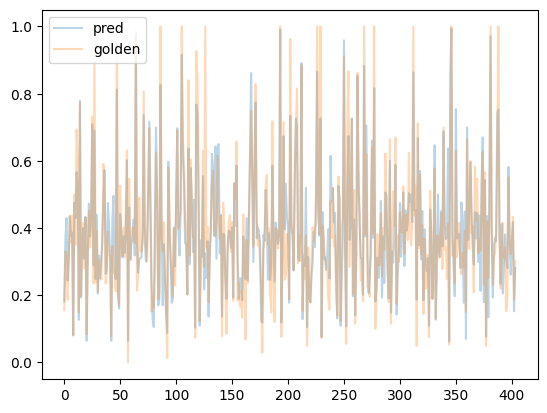

In [19]:
dfPred = pd.Series(np.concatenate(trainPredicts))
dfGolden = pd.Series(scaledObjTrain.flatten())
dfPredVsGoldenTrain = pd.concat([dfPred, dfGolden], axis=1)
dfPredVsGoldenTrain.columns = ['pred', 'golden']
dfPredVsGoldenTrain.plot(alpha=0.3)

<Axes: ylabel='Frequency'>

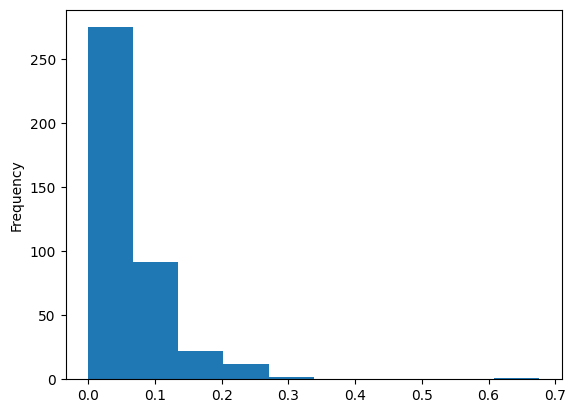

In [20]:
error = dfPred-dfGolden
error.abs().plot.hist()

# スケールを戻す

In [21]:
naEval = np.array(evalResult.predicts)
scalerObj.inverse_transform(naEval.reshape(-1, 1))[:5, :]

array([[28.46679688],
       [34.53125   ],
       [17.65625   ],
       [27.23632812],
       [16.07421875]])